# 11. Penalty coefficient 실험 결과 시각화

notebook 10의 결과로 Figure 8~11을 만듭니다.

| Figure | 내용 | 확인할 것 |
|---|---|---|
| 8 | lambda 대 QUBO 계수 범위 | lambda에 정확히 비례하는가 |
| 9 | lambda 대 feasible 비율 (SA vs QA) | **두 가설을 구분하는 핵심 그림** |
| 10 | lambda 대 true optimality gap | 품질도 함께 개선되는가 |
| 11 | 정규화된 objective 계수와 ICE 노이즈 | 어느 lambda에서 objective가 보이는가 |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from src.config import load_config, resolve_path

config = load_config(PROJECT_ROOT / "config" / "experiment_config.yaml")
DATA_DIR = resolve_path(config, "data_dir")
RAW_DIR = resolve_path(config, "raw_dir")
PROCESSED_DIR = resolve_path(config, "processed_dir")
FIGURE_DIR = resolve_path(config, "figure_dir")
SOLUTION_DIR = RAW_DIR / "solutions"

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
print("설정 로드 완료")


설정 로드 완료


In [3]:
from src.persistence import load_table
from src import lambda_plotting as LP

results = load_table(PROCESSED_DIR, "lambda_sweep.csv")
print("solver별 행 수:")
print(results.groupby("solver").size())
results

solver별 행 수:
solver
QA    12
SA    12
dtype: int64


,instance,formulation,multiplier,lambda_value,qubo_min,qubo_max,qubo_range,max_abs_coupling,scaled_objective_coefficient,solver,status,feasible_fraction,best_feasible_objective,true_gap_percent,ground_state_is_feasible,runtime,qa_chain_strength,qa_chain_break_fraction,physical_qubits,max_chain_length
0,4x4,SS,0.10,241.68364,-1.251921e+06,1.185197e+06,2.437118e+06,3.129803e+05,0.000211,SA,OK,0.012,2416.8364,0.000000,False,0.420549,NaN,NaN,NaN,NaN
1,4x4,SS,0.25,604.20910,-3.129803e+06,2.961571e+06,6.091375e+06,7.824508e+05,0.000084,SA,OK,0.019,2416.8364,0.000000,True,0.419482,NaN,NaN,NaN,NaN
2,4x4,SS,0.50,1208.41820,-6.259606e+06,5.922196e+06,1.218180e+07,1.564902e+06,0.000042,SA,OK,0.016,2416.8364,0.000000,True,0.423623,NaN,NaN,NaN,NaN
3,4x4,SS,0.75,1812.62730,-9.389409e+06,8.882821e+06,1.827223e+07,2.347352e+06,0.000028,SA,OK,0.008,3143.7096,30.075399,True,0.420932,NaN,NaN,NaN,NaN
4,4x4,SS,1.00,2416.83640,-1.251921e+07,1.184345e+07,2.436266e+07,3.129803e+06,0.000021,SA,OK,0.010,2416.8364,0.000000,True,0.421454,NaN,NaN,NaN,NaN
5,4x4,SS,1.25,3021.04550,-1.564902e+07,1.480407e+07,3.045309e+07,3.912254e+06,0.000017,SA,OK,0.008,2602.8229,7.695453,True,0.420968,NaN,NaN,NaN,NaN
6,4x4,SS,1.50,3625.25460,-1.877882e+07,1.776469e+07,3.654351e+07,4.694705e+06,0.000014,SA,OK,0.007,2426.5714,0.402799,True,0.424462,NaN,NaN,NaN,NaN
7,4x4,SS,2.00,4833.67280,-2.503843e+07,2.368594e+07,4.872437e+07,6.259606e+06,0.000011,SA,OK,0.011,2416.8364,0.000000,True,0.422782,NaN,NaN,NaN,NaN
8,4x4,SS,3.00,7250.50920,-3.755764e+07,3.552844e+07,7.308608e+07,9.389409e+06,0.000007,SA,OK,0.006,2970.7976,22.920923,True,0.422132,NaN,NaN,NaN,NaN
9,4x4,SS,5.00,12084.18200,-6.259606e+07,5.921344e+07,1.218095e+08,1.564902e+07,0.000004,SA,OK,0.013,2426.5714,0.402799,True,0.422647,NaN,NaN,NaN,NaN


## Figure 8 — lambda와 계수 범위

penalty term이 제곱 형태이므로 계수는 `lambda x (제약계수)^2` 규모가 됩니다. 제약계수는 lambda와 무관하므로 **계수 범위는 lambda에 정확히 비례**해야 합니다. 그래프가 직선(log-log)이면 구현이 의도대로 된 것입니다.

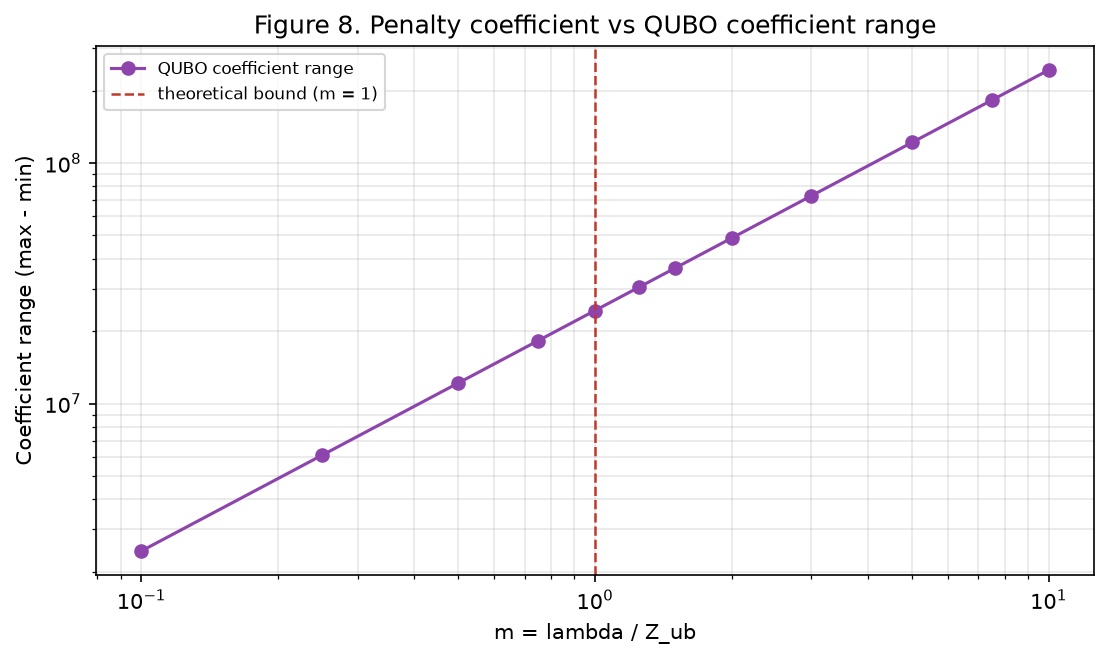

In [4]:
path = LP.plot_lambda_vs_range(results, FIGURE_DIR)
from IPython.display import Image
Image(filename=str(path))

## Figure 9 — lambda와 feasible 비율 (핵심)

이 그림 하나가 두 가설을 구분합니다.

- **QA 곡선만 왼쪽에서 올라가면** → 가설 A(precision)
- **SA와 QA가 함께 올라가면** → 가설 B(landscape)의 기여가 큼
- **둘 다 평평하면** → lambda 외의 요인

세로 점선은 이론적 경계(m = 1)입니다. 그 왼쪽은 ground state가 feasible 이라는 보장이 없는 영역이므로, 결과가 좋아 보여도 **해로 채택할 수 없습니다.** 진단용으로만 읽으십시오.

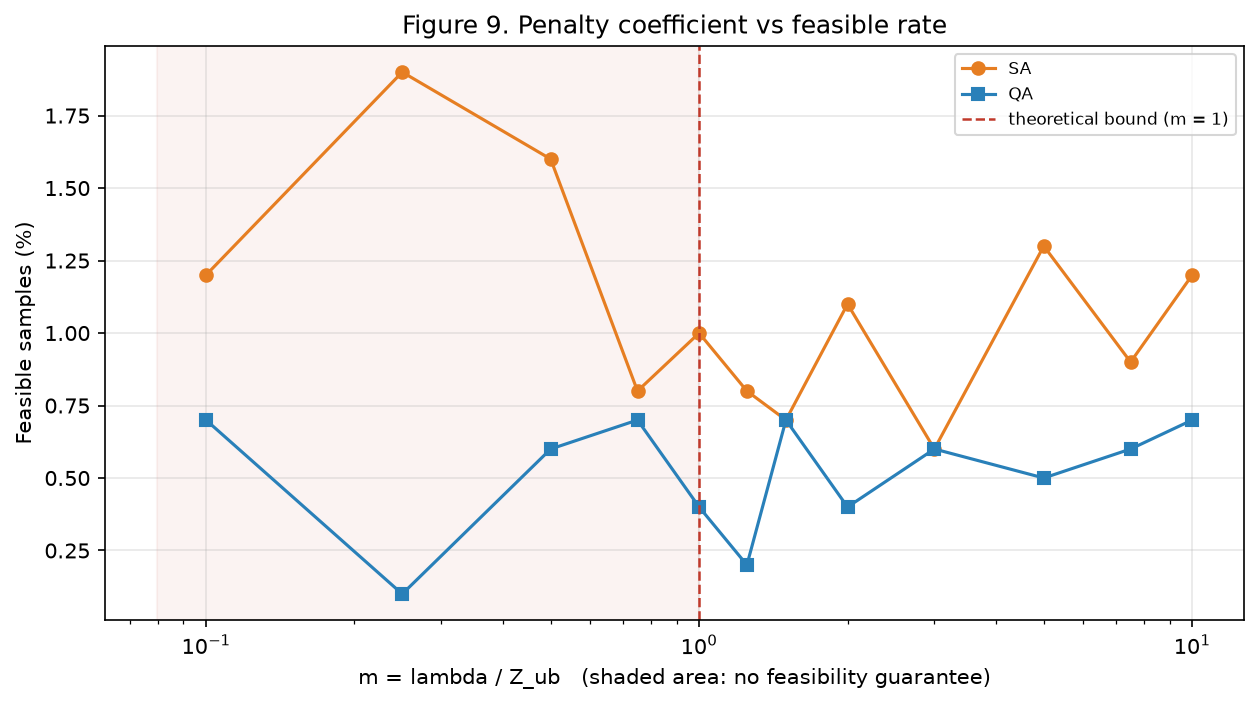

In [5]:
path = LP.plot_lambda_vs_feasibility(results, FIGURE_DIR)
Image(filename=str(path))

## Figure 10 — lambda와 optimality gap

feasible solution을 찾는 것과 좋은 solution을 찾는 것은 다릅니다. feasible 비율이 올라가도 gap이 그대로면, penalty를 낮춘 효과가 **품질까지 이어지지는 않는다**는 뜻입니다.

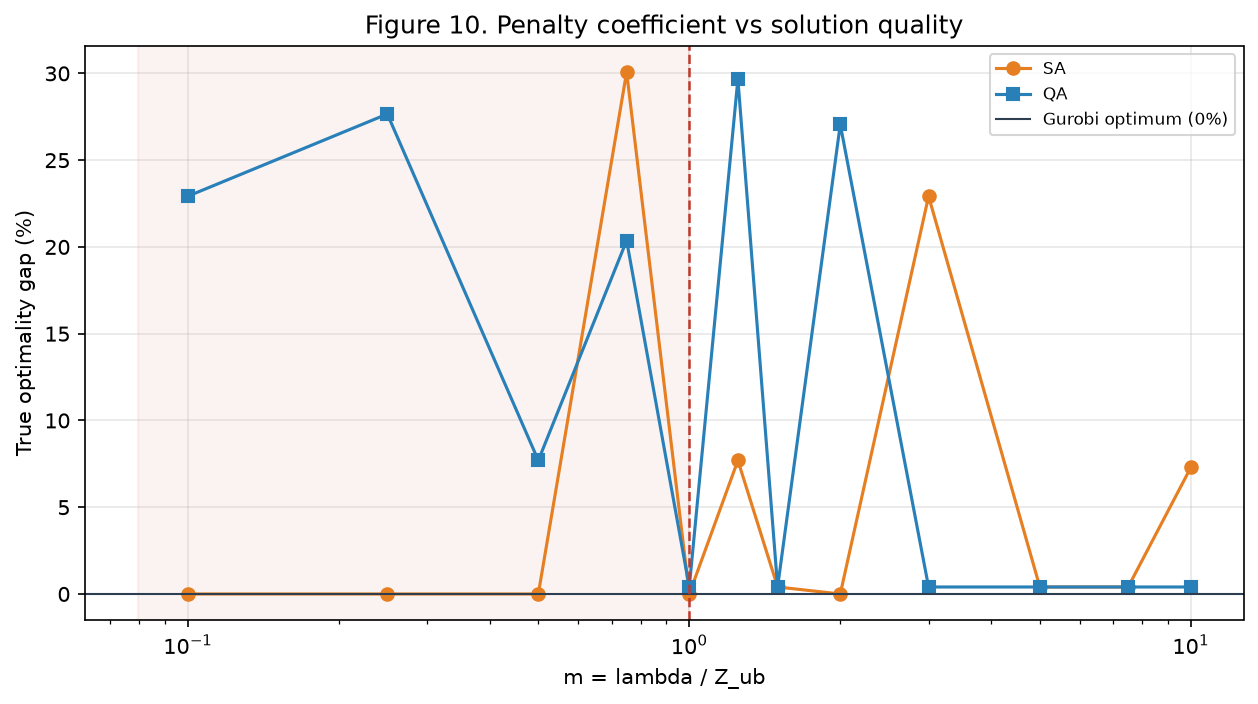

In [6]:
path = LP.plot_lambda_vs_gap(results, FIGURE_DIR)
Image(filename=str(path))

## Figure 11 — objective 계수와 하드웨어 노이즈

D-Wave는 모든 계수를 max|J|로 나누어 하드웨어 범위에 맞춥니다. 그 결과 원래 objective 계수가 얼마나 작아지는지를 ICE 노이즈 수준과 비교합니다.

회색 띠 아래에 있으면 objective가 노이즈에 묻혀 하드웨어가 구분할 수 없다는 뜻입니다. **이 그림에서 모든 점이 띠 아래에 있다면, lambda 조정 만으로는 QA를 살릴 수 없다는 정량적 근거가 됩니다.**

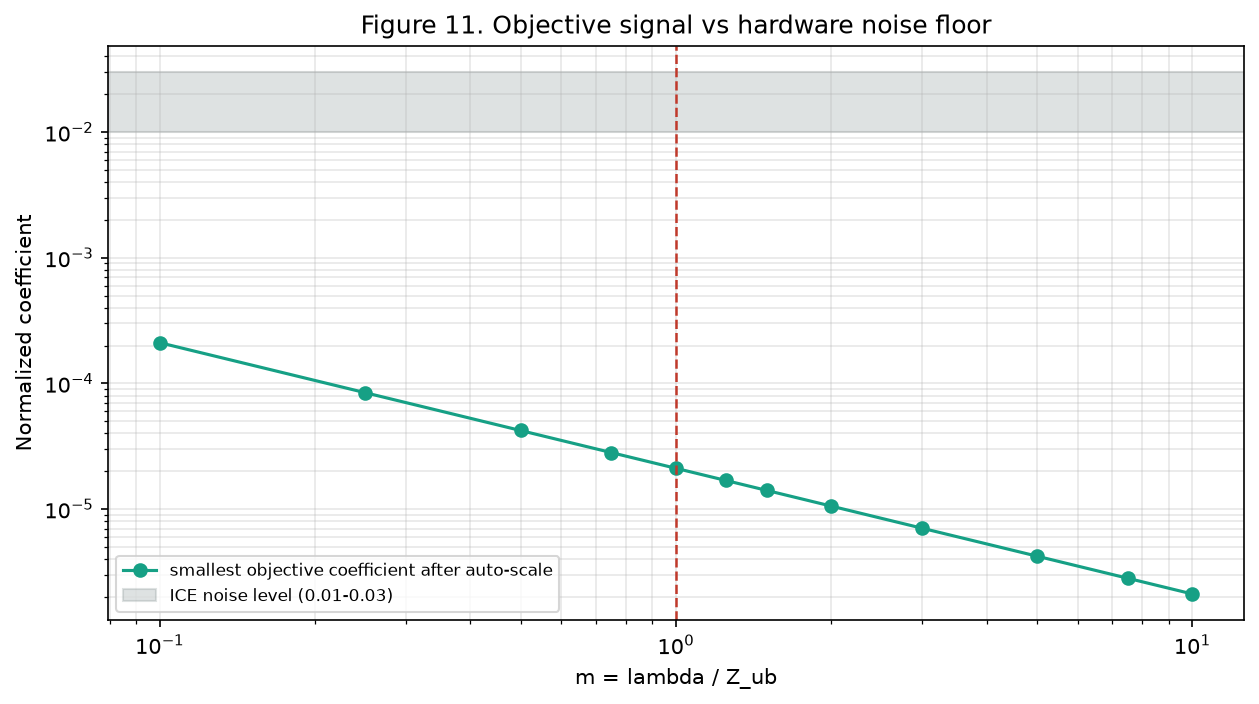

In [7]:
path = LP.plot_scaled_objective(results, FIGURE_DIR)
Image(filename=str(path))

## 요약

아래 출력은 관측된 수치만 기술합니다. lambda를 낮춰 결과가 좋아지더라도, m < 1 구간은 이론적 보장이 없으므로 본 실험의 설정으로 채택할 수 없습니다.

In [8]:
from src import lambda_experiment as LE

lines = LE.interpret(results)
for line in lines:
    print(line)

summary_path = PROCESSED_DIR / "lambda_summary.txt"
summary_path.write_text("\n".join(lines), encoding="utf-8")
print("\n저장:", summary_path)

SA: lambda 낮은 구간 feasible 0.013 vs 높은 구간 0.010 (차이 +0.003)
QA: lambda 낮은 구간 feasible 0.005 vs 높은 구간 0.006 (차이 -0.001)
=> 둘 다 반응 없음. lambda 외의 요인을 찾아야 합니다.

저장: C:\Users\User\Desktop\KMJ\Study\Quantum\cflp_formulation\results\processed\lambda_summary.txt
